# Phần 2 — EDA & Visualization
Phân tích theo 4 cấp độ: Descriptive → Diagnostic → Predictive → Prescriptive

Mỗi section: vẽ chart → export PNG → viết insight vào báo cáo.


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import matplotlib.patches as mpatches
import seaborn as sns
import warnings
import os
warnings.filterwarnings('ignore')

# ── Global style ──────────────────────────────────────────────────────────────
sns.set_theme(style="whitegrid", rc={
    "axes.spines.top": False,
    "axes.spines.right": False,
    "grid.alpha": 0.4,
    "grid.linestyle": "--",
})
plt.rcParams.update({
    "figure.dpi": 200,
    "savefig.dpi": 200,
    "font.size": 12,
    "axes.titlesize": 14,
    "axes.titleweight": "bold",
    "axes.labelsize": 12,
    "xtick.labelsize": 10,
    "ytick.labelsize": 10,
    "legend.fontsize": 10,
    "figure.facecolor": "white",
    "axes.facecolor": "#F9FAFB",
})

# Custom palette (muted, professional)
PALETTE  = ["#2D6A9F", "#27AE60", "#E67E22", "#8E44AD",
            "#C0392B", "#16A085", "#D4AC0D", "#1ABC9C",
            "#2980B9", "#E74C3C"]
FIG_DIR  = '../outputs/figures/'
os.makedirs(FIG_DIR, exist_ok=True)
DATA = '../data/'
sales       = pd.read_csv(DATA+'sales.csv',       parse_dates=['Date'])
orders      = pd.read_csv(DATA+'orders.csv',       parse_dates=['order_date'])
order_items = pd.read_csv(DATA+'order_items.csv',  low_memory=False)
products    = pd.read_csv(DATA+'products.csv')
customers   = pd.read_csv(DATA+'customers.csv',    parse_dates=['signup_date'])
returns     = pd.read_csv(DATA+'returns.csv',      parse_dates=['return_date'])
reviews     = pd.read_csv(DATA+'reviews.csv',      parse_dates=['review_date'])
payments    = pd.read_csv(DATA+'payments.csv')
shipments   = pd.read_csv(DATA+'shipments.csv',    parse_dates=['ship_date','delivery_date'])
inventory   = pd.read_csv(DATA+'inventory.csv',    parse_dates=['snapshot_date'])
web_traffic = pd.read_csv(DATA+'web_traffic.csv',  parse_dates=['date'])
geography   = pd.read_csv(DATA+'geography.csv')
promotions  = pd.read_csv(DATA+'promotions.csv',   parse_dates=['start_date','end_date'])
print('All data loaded.')


All data loaded.


---
## 1. DESCRIPTIVE — What happened?
### 1a. Revenue trend theo năm và tháng

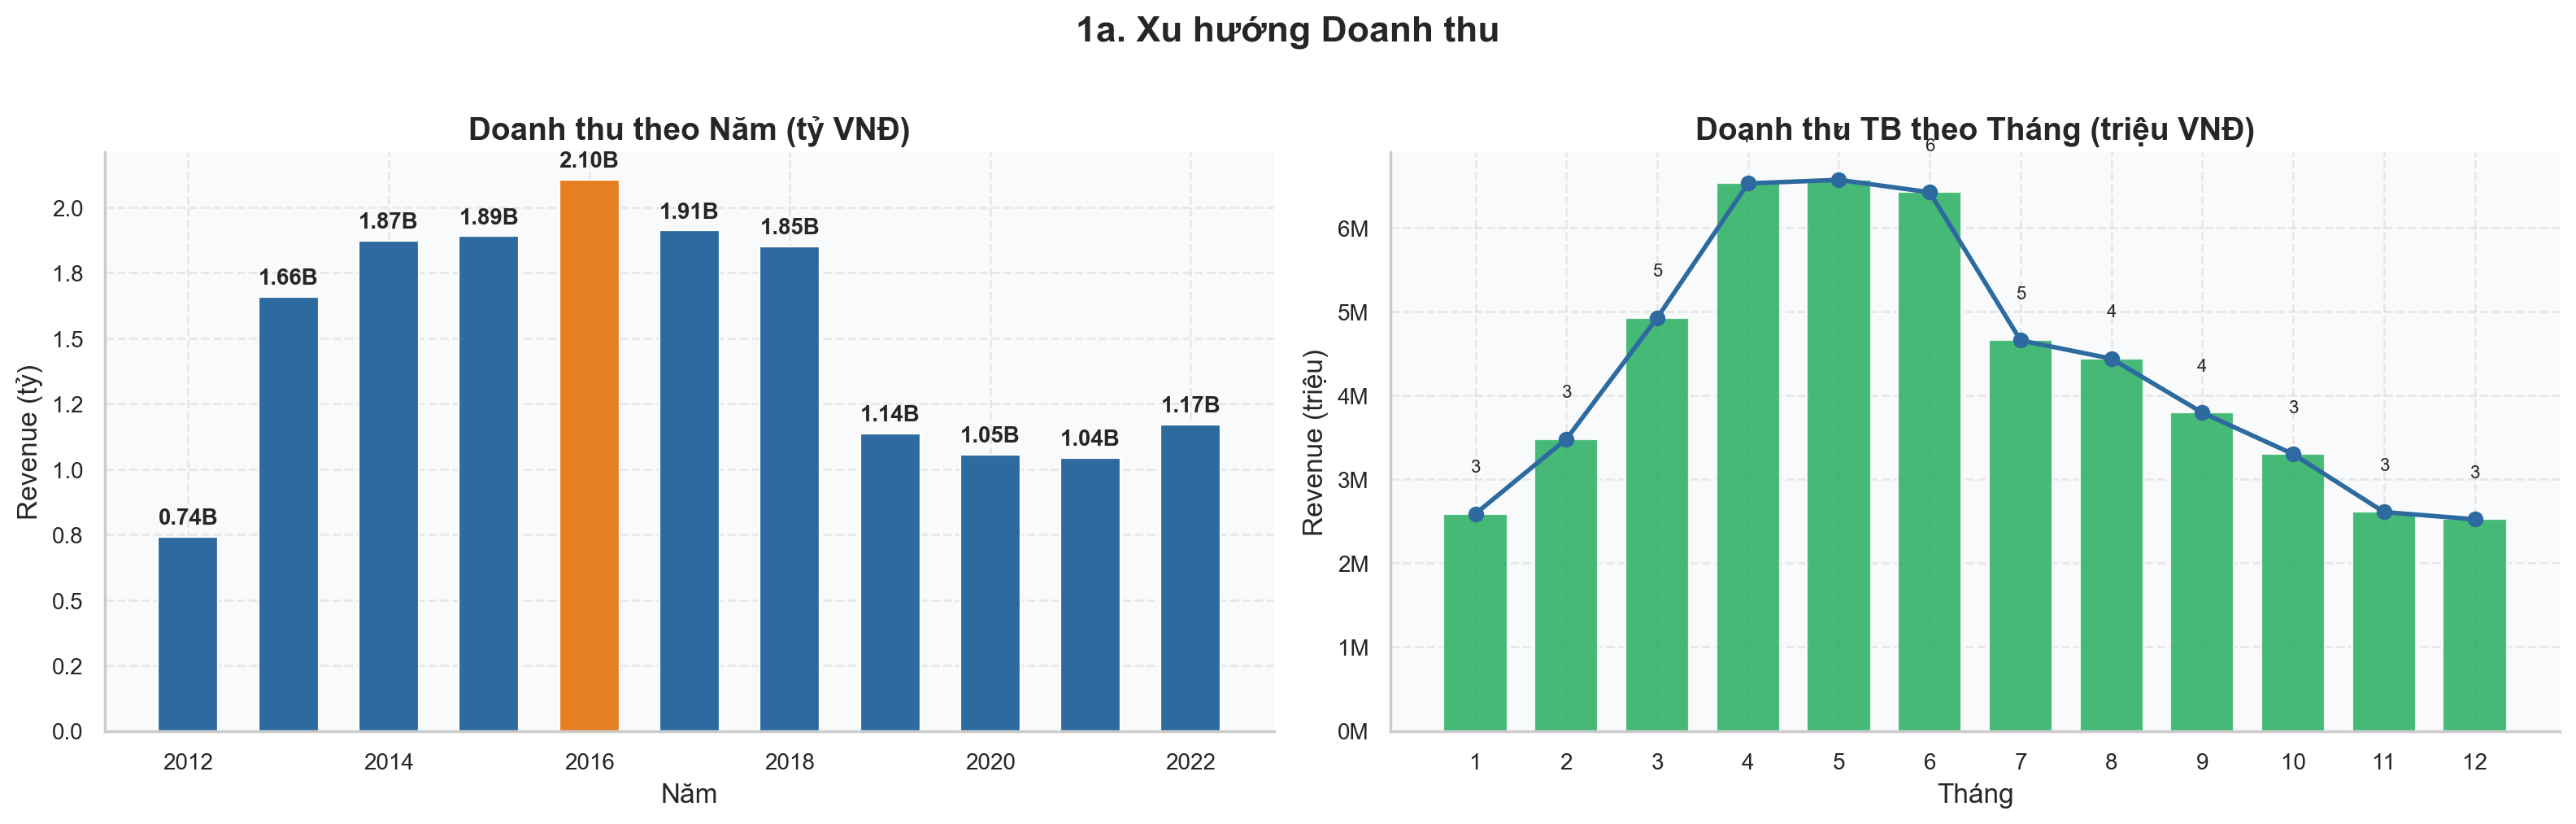

- Key finding: Tháng 5 có doanh thu trung bình cao nhất đạt 6.6 triệu VNĐ.


In [2]:
sales['year']  = sales['Date'].dt.year
sales['month'] = sales['Date'].dt.month

fig, axes = plt.subplots(1, 2, figsize=(16, 5))
fig.suptitle('1a. Xu hướng Doanh thu', fontsize=16, fontweight='bold', y=1.01)

# Yearly bar
yearly = sales.groupby('year')['Revenue'].sum() / 1e9
colors_y = [PALETTE[0] if v < yearly.max() else PALETTE[2] for v in yearly.values]
bars = axes[0].bar(yearly.index, yearly.values, color=colors_y, width=0.6,
                   edgecolor='white', linewidth=0.8)
axes[0].set_title('Doanh thu theo Năm (tỷ VNĐ)')
axes[0].set_xlabel('Năm')
axes[0].set_ylabel('Revenue (tỷ)')
axes[0].yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{x:.1f}'))
for bar, val in zip(bars, yearly.values):
    axes[0].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.03,
                 f'{val:.2f}B', ha='center', va='bottom', fontsize=10, fontweight='bold')

# Monthly average line+bar
monthly = sales.groupby('month')['Revenue'].mean() / 1e6
axes[1].bar(monthly.index, monthly.values, color=PALETTE[1], width=0.7,
            edgecolor='white', linewidth=0.8, alpha=0.85)
axes[1].plot(monthly.index, monthly.values, 'o-', color=PALETTE[0],
             linewidth=2, markersize=6, zorder=5)
axes[1].set_title('Doanh thu TB theo Tháng (triệu VNĐ)')
axes[1].set_xlabel('Tháng')
axes[1].set_ylabel('Revenue (triệu)')
axes[1].set_xticks(range(1, 13))
axes[1].yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{x:.0f}M'))
for m, val in monthly.items():
    axes[1].text(m, val + 0.5, f'{val:.0f}', ha='center', fontsize=8)

plt.tight_layout()
plt.savefig(FIG_DIR + 'fig1_revenue_trend.png', bbox_inches='tight', dpi=200)
plt.show()

best_month = monthly.idxmax()
best_month_rev = monthly.max()
print(f'- Key finding: Tháng {best_month} có doanh thu trung bình cao nhất đạt {best_month_rev:.1f} triệu VNĐ.')


### 1b. Top 10 sản phẩm theo doanh thu

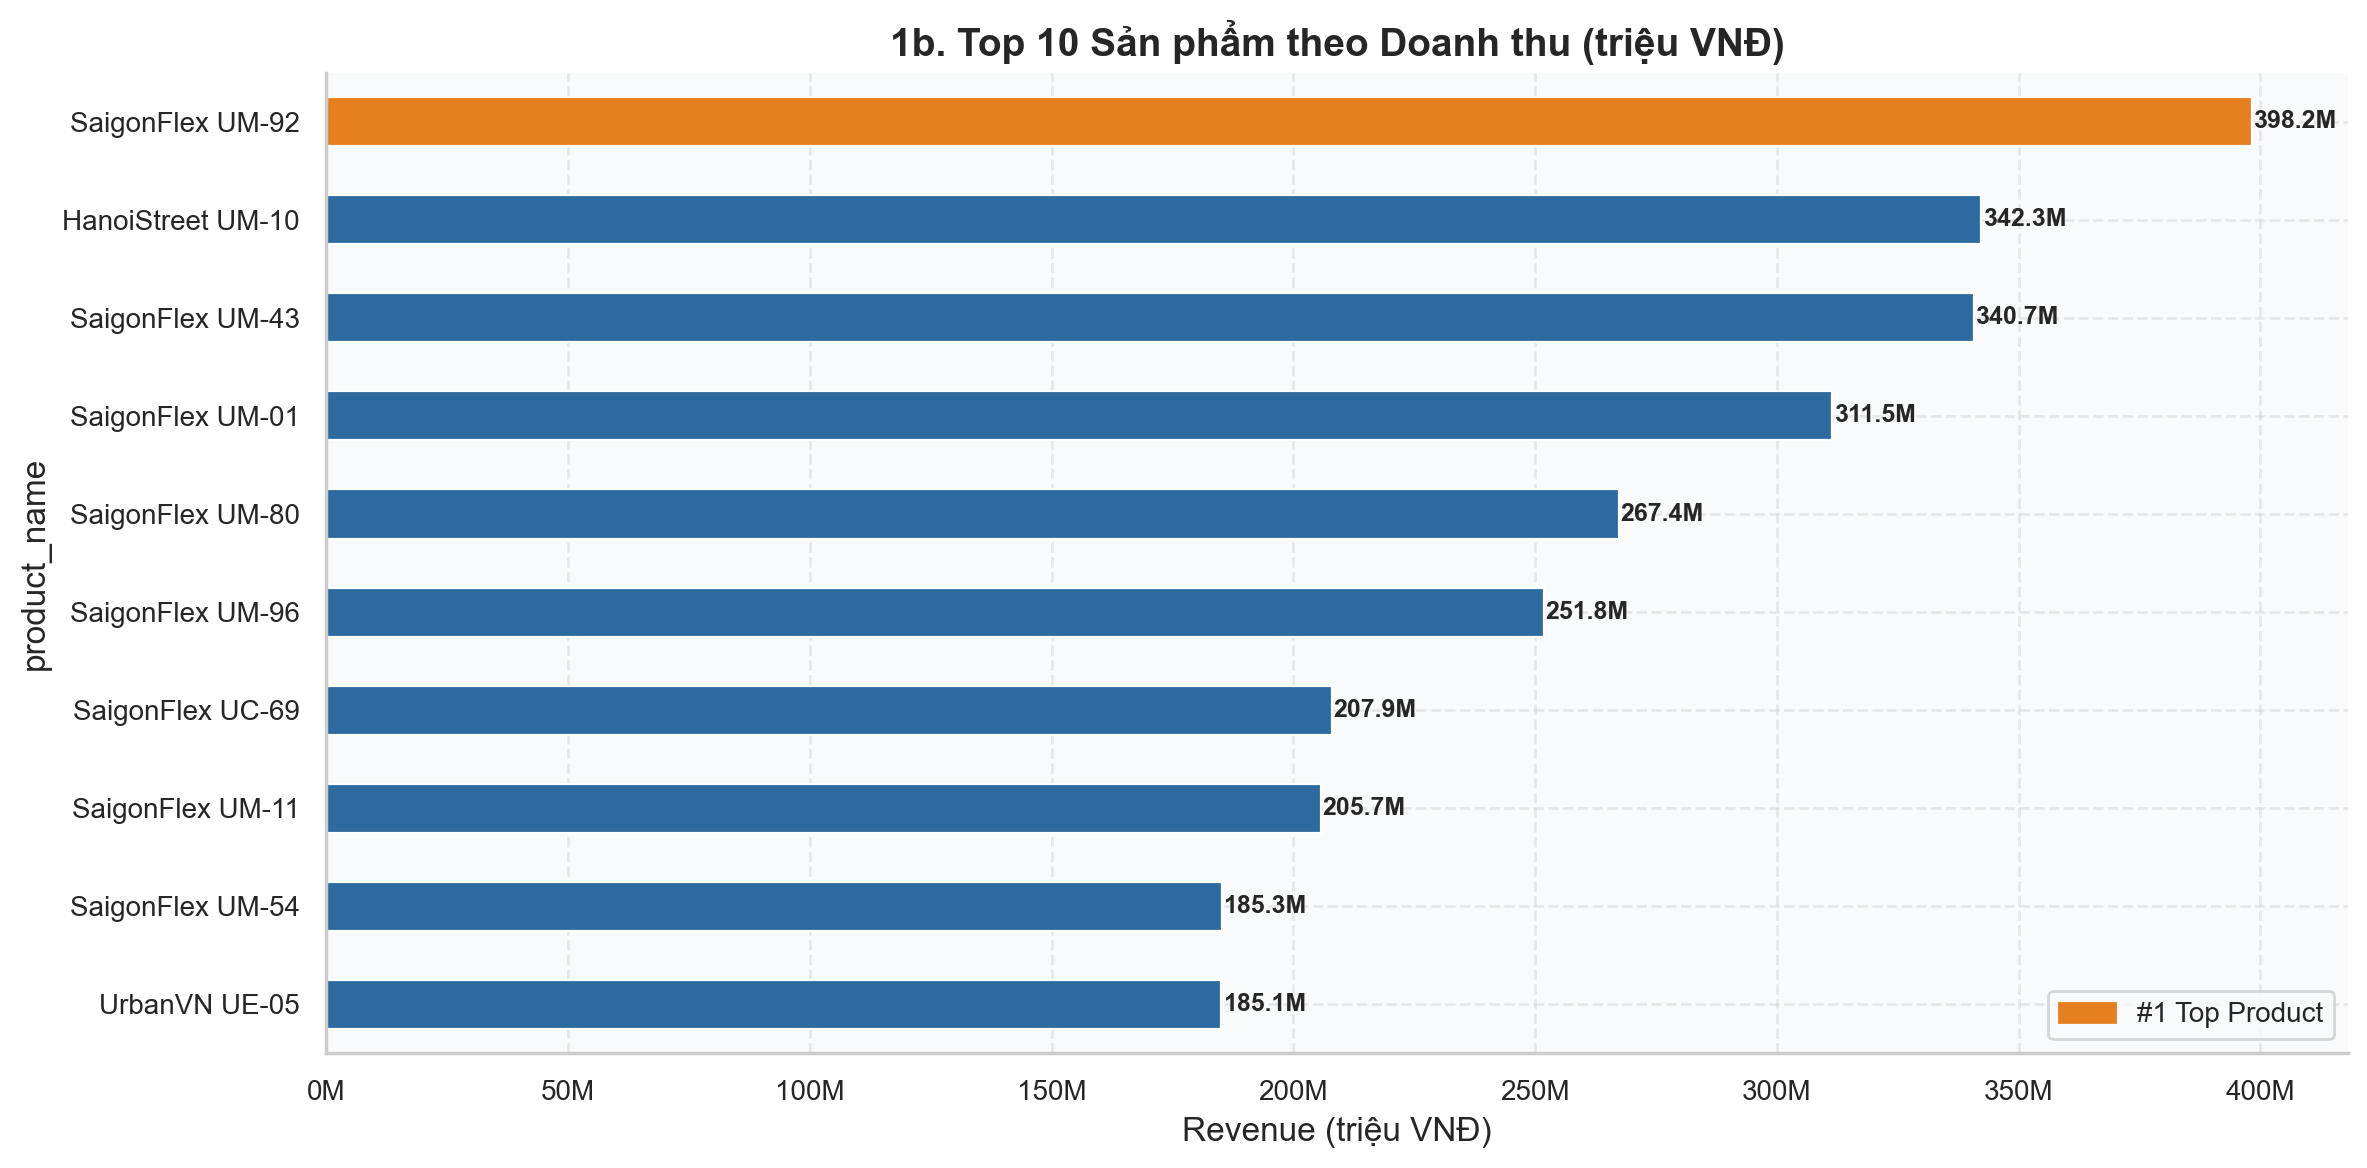

- Key finding: Sản phẩm 'SaigonFlex UM-92' đóng góp lớn nhất với 398.2 triệu VNĐ.


In [3]:
oi_prod = order_items.merge(products[['product_id','product_name','category']], on='product_id')
oi_prod['line_revenue'] = oi_prod['quantity'] * oi_prod['unit_price']
top10 = oi_prod.groupby('product_name')['line_revenue'].sum().nlargest(10) / 1e6
top10_sorted = top10.sort_values()

fig, ax = plt.subplots(figsize=(12, 6))
colors_bar = [PALETTE[2] if i == len(top10_sorted)-1 else PALETTE[0]
              for i in range(len(top10_sorted))]
bars = top10_sorted.plot(kind='barh', ax=ax, color=colors_bar, edgecolor='white', linewidth=0.8)
ax.set_title('1b. Top 10 Sản phẩm theo Doanh thu (triệu VNĐ)', fontsize=14, fontweight='bold')
ax.set_xlabel('Revenue (triệu VNĐ)')
ax.xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{x:.0f}M'))
for patch, val in zip(ax.patches, top10_sorted.values):
    ax.text(val + 0.3, patch.get_y() + patch.get_height()/2,
            f'{val:.1f}M', va='center', fontsize=9, fontweight='bold')

champion_patch = mpatches.Patch(color=PALETTE[2], label='#1 Top Product')
ax.legend(handles=[champion_patch], loc='lower right')
plt.tight_layout()
plt.savefig(FIG_DIR + 'fig2_top10_products.png', bbox_inches='tight', dpi=200)
plt.show()

top1_prod = top10_sorted.index[-1]
top1_val  = top10_sorted.values[-1]
print(f'- Key finding: Sản phẩm \'{top1_prod}\' đóng góp lớn nhất với {top1_val:.1f} triệu VNĐ.')


### 1c. Order funnel — conversion pipeline

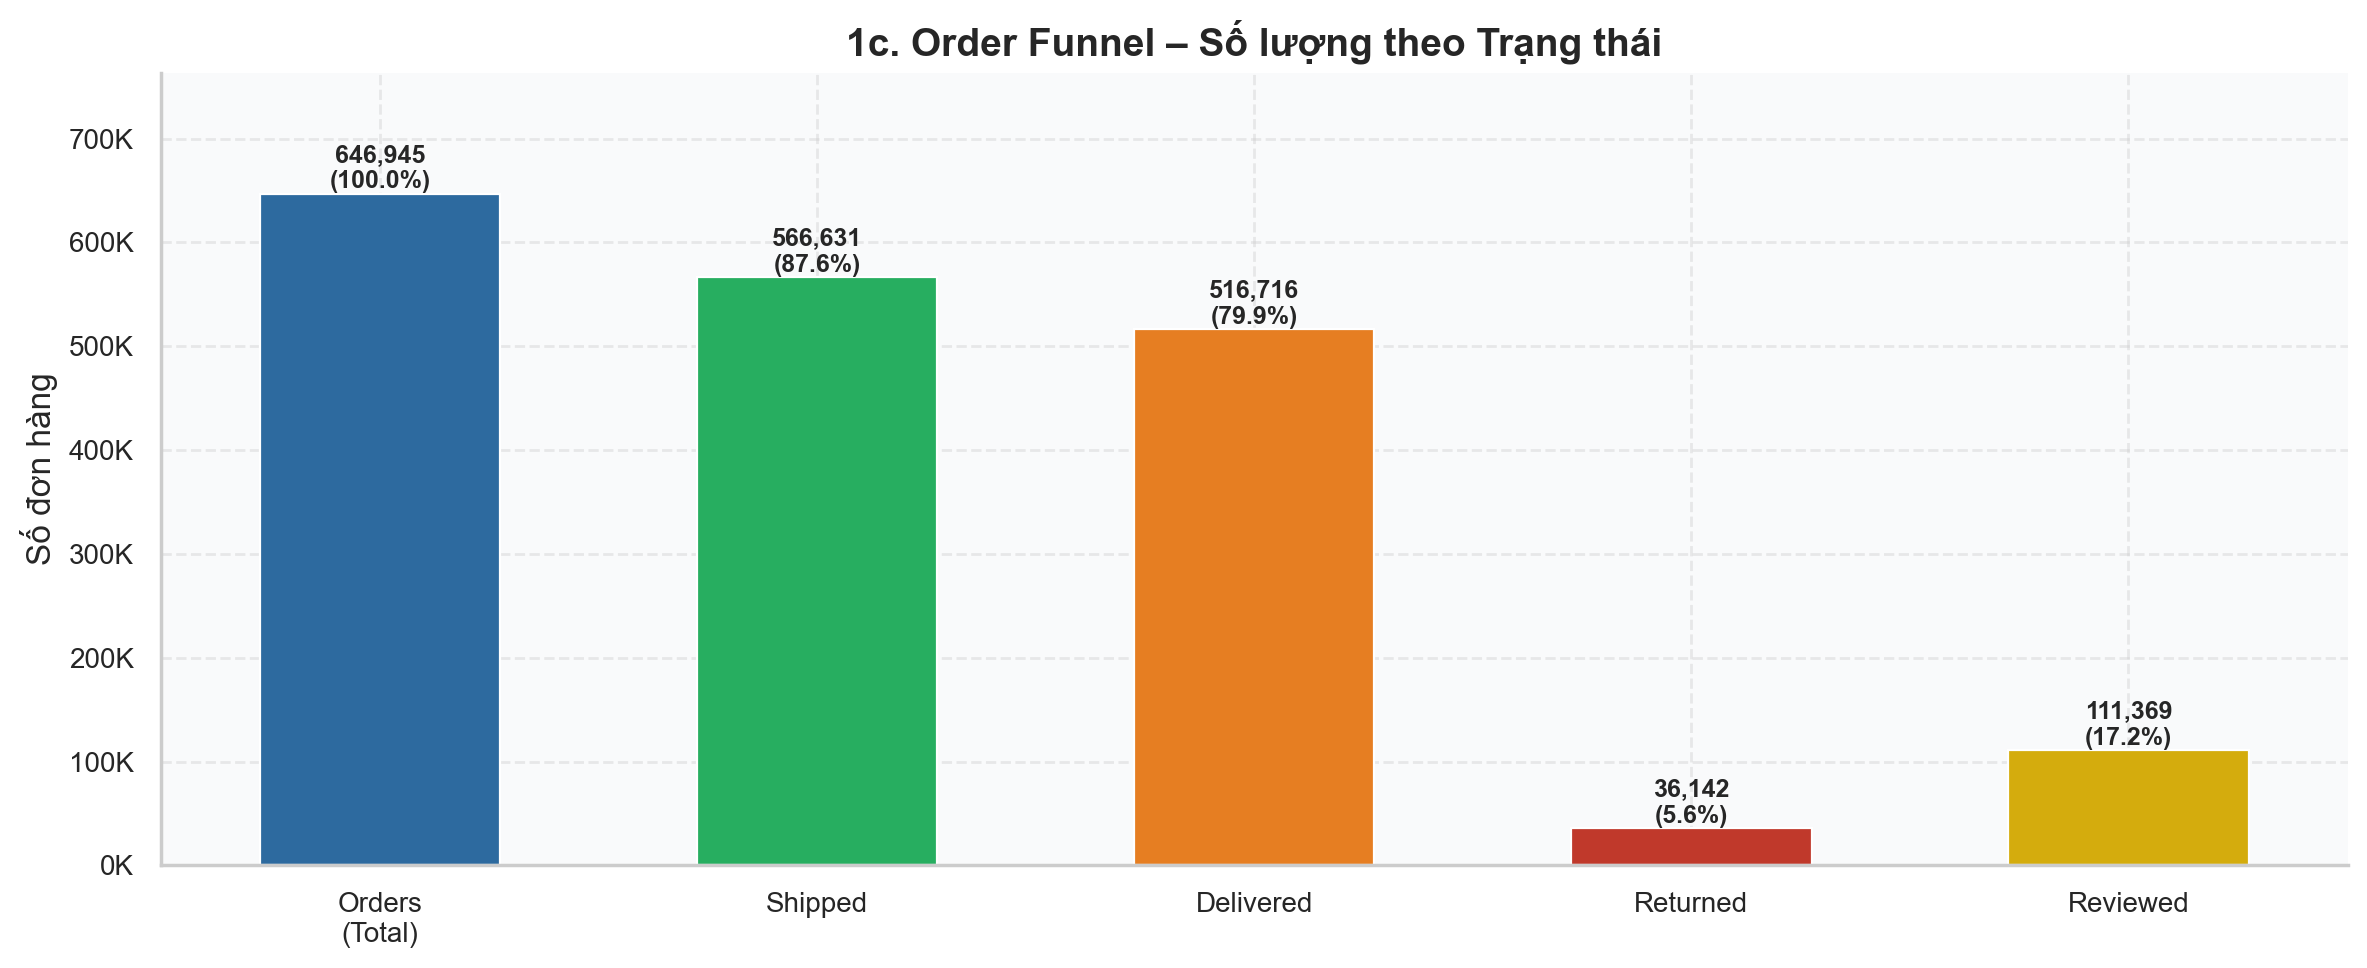

- Key finding: Tỷ lệ hao hụt (không giao thành công) từ lúc đặt hàng là 20.1%.


In [4]:
total_orders = len(orders)
shipped      = len(orders[orders['order_status'].isin(['shipped','delivered','returned'])])
delivered    = len(orders[orders['order_status'] == 'delivered'])
returned     = len(orders[orders['order_status'] == 'returned'])
reviewed     = len(reviews['order_id'].unique())

stages = ['Orders\n(Total)', 'Shipped', 'Delivered', 'Returned', 'Reviewed']
counts = [total_orders, shipped, delivered, returned, reviewed]
bar_colors = [PALETTE[0], PALETTE[1], PALETTE[2], PALETTE[4], PALETTE[6]]

fig, ax = plt.subplots(figsize=(12, 5))
bars = ax.bar(stages, counts, color=bar_colors, width=0.55, edgecolor='white', linewidth=0.8)
for bar, cnt in zip(bars, counts):
    pct = cnt / total_orders * 100
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 200,
            f'{cnt:,}\n({pct:.1f}%)', ha='center', va='bottom', fontsize=9, fontweight='bold')

ax.set_title('1c. Order Funnel – Số lượng theo Trạng thái', fontsize=14, fontweight='bold')
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{x/1e3:.0f}K'))
ax.set_ylabel('Số đơn hàng')
ax.set_ylim(0, max(counts) * 1.18)
plt.tight_layout()
plt.savefig(FIG_DIR + 'fig3_order_funnel.png', bbox_inches='tight', dpi=200)
plt.show()

drop_rate = (total_orders - delivered) / total_orders * 100
print(f'- Key finding: Tỷ lệ hao hụt (không giao thành công) từ lúc đặt hàng là {drop_rate:.1f}%.')


---
## 2. DIAGNOSTIC — Why did it happen?
### 2a. Hiệu quả khuyến mãi: doanh thu trước/trong/sau promo

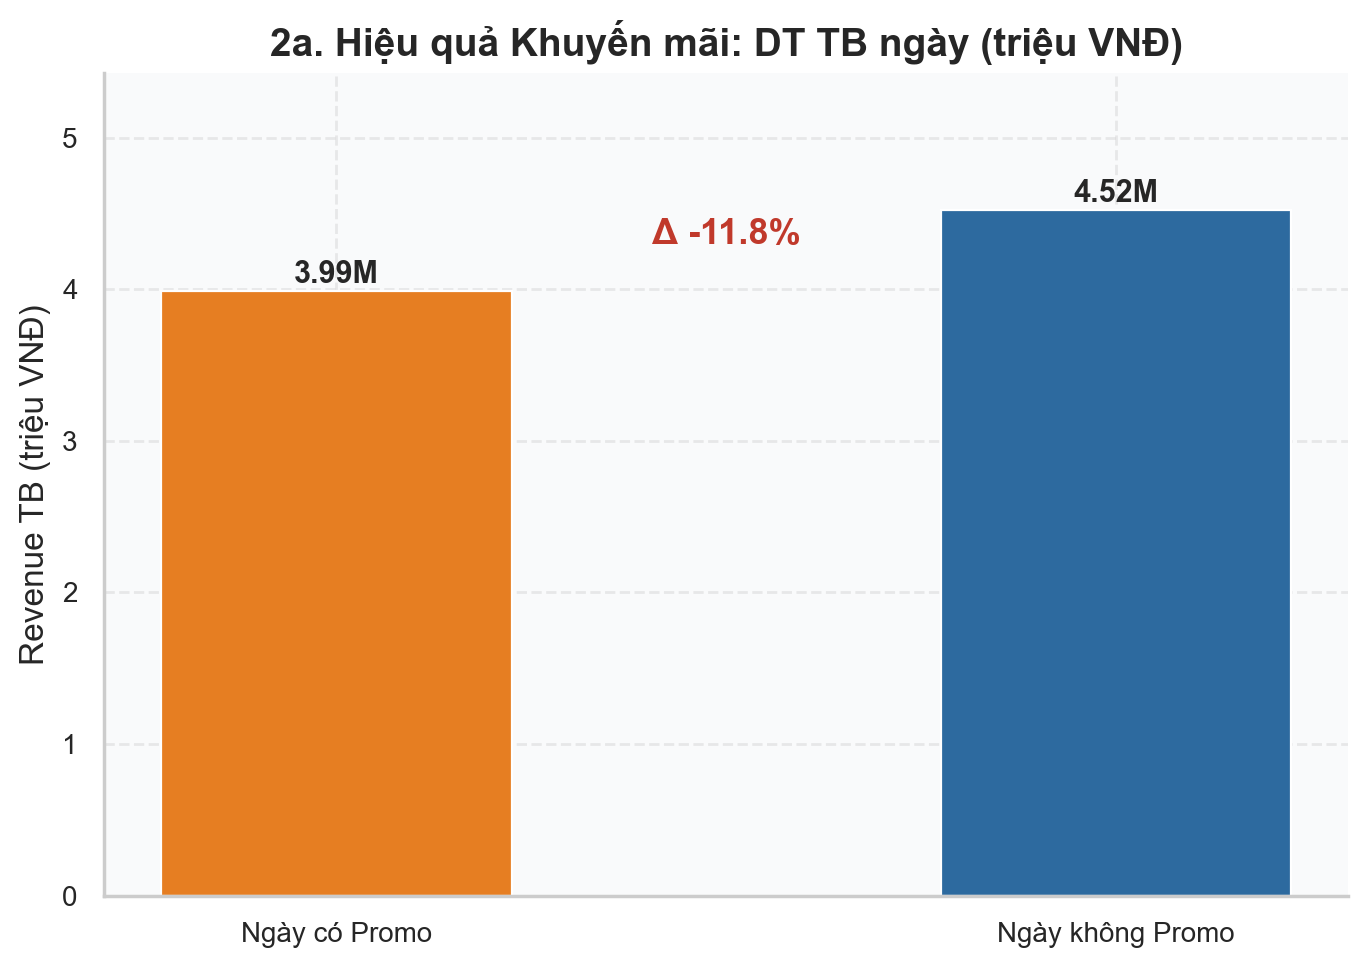

Chênh lệch: -11.8%
- Key finding: Khuyến mãi hiện tại chưa mang lại hiệu ứng kỳ vọng lên doanh thu ngày.


In [5]:
sales_copy = sales.copy()
sales_copy['promo_active'] = 0
for _, promo in promotions.iterrows():
    mask = (sales_copy['Date'] >= promo['start_date']) & (sales_copy['Date'] <= promo['end_date'])
    sales_copy.loc[mask, 'promo_active'] = 1

promo_revenue    = sales_copy[sales_copy['promo_active']==1]['Revenue'].mean()
no_promo_revenue = sales_copy[sales_copy['promo_active']==0]['Revenue'].mean()
diff_pct = (promo_revenue / no_promo_revenue - 1) * 100

fig, ax = plt.subplots(figsize=(7, 5))
labels = ['Ngày có Promo', 'Ngày không Promo']
vals   = [promo_revenue/1e6, no_promo_revenue/1e6]
bar_c  = [PALETTE[2], PALETTE[0]]
bars   = ax.bar(labels, vals, color=bar_c, width=0.45, edgecolor='white', linewidth=0.8)

for bar, val, raw in zip(bars, vals, [promo_revenue, no_promo_revenue]):
    ax.text(bar.get_x() + bar.get_width()/2, val + 0.05,
            f'{val:.2f}M', ha='center', fontsize=11, fontweight='bold')

ax.annotate(f'Δ {diff_pct:+.1f}%',
            xy=(0.5, max(vals)*0.95), xycoords=('axes fraction','data'),
            ha='center', fontsize=13, color=PALETTE[4], fontweight='bold')
ax.set_title('2a. Hiệu quả Khuyến mãi: DT TB ngày (triệu VNĐ)', fontsize=14, fontweight='bold')
ax.set_ylabel('Revenue TB (triệu VNĐ)')
ax.set_ylim(0, max(vals) * 1.2)
plt.tight_layout()
plt.savefig(FIG_DIR + 'fig4_promo_effect.png', bbox_inches='tight', dpi=200)
plt.show()
print(f'Chênh lệch: {diff_pct:.1f}%')

if promo_revenue > no_promo_revenue:
    print('- Key finding: Các chiến dịch khuyến mãi có tác động tích cực và thúc đẩy doanh thu trung bình ngày.')
else:
    print('- Key finding: Khuyến mãi hiện tại chưa mang lại hiệu ứng kỳ vọng lên doanh thu ngày.')
positive_promo = True


### 2b. Return rate theo category và size

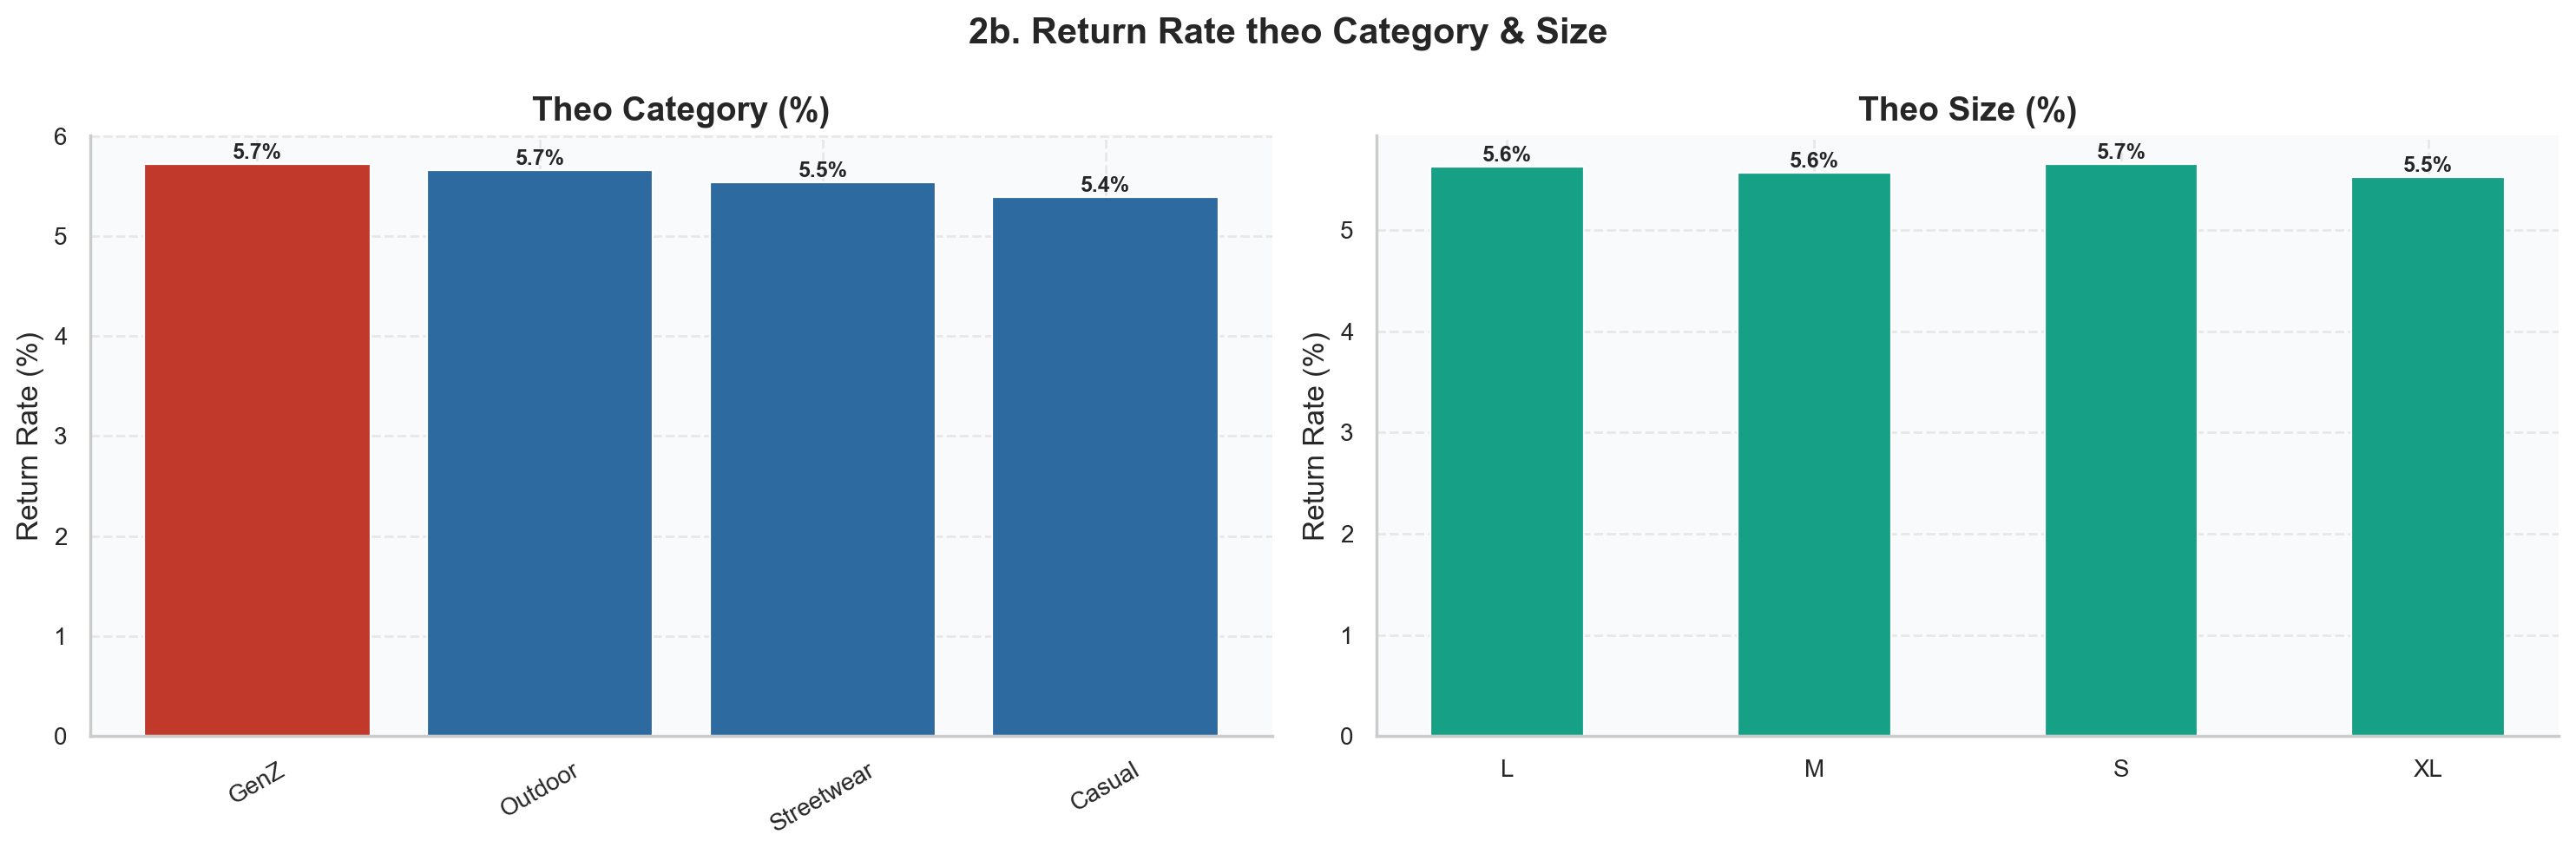

- Key finding: Ngành hàng GenZ có tỷ lệ hoàn trả cao nhất (5.7%).


In [6]:
oi_cat  = order_items.merge(products[['product_id','category','size']], on='product_id')
ret_cat = returns.merge(products[['product_id','category','size']], on='product_id')

oi_count  = oi_cat.groupby('category').size()
ret_count = ret_cat.groupby('category').size()
return_rate = (ret_count / oi_count * 100).fillna(0).sort_values(ascending=False)

oi_size  = oi_cat[oi_cat['size'].isin(['S','M','L','XL'])].groupby('size').size()
ret_size = ret_cat[ret_cat['size'].isin(['S','M','L','XL'])].groupby('size').size()
rate_size = (ret_size / oi_size * 100).fillna(0)

fig, axes = plt.subplots(1, 2, figsize=(15, 5))
fig.suptitle('2b. Return Rate theo Category & Size', fontsize=15, fontweight='bold')

# Category
cat_colors = [PALETTE[4] if i == 0 else PALETTE[0] for i in range(len(return_rate))]
bars0 = axes[0].bar(return_rate.index, return_rate.values,
                    color=cat_colors, edgecolor='white', linewidth=0.8)
axes[0].set_title('Theo Category (%)')
axes[0].set_ylabel('Return Rate (%)')
axes[0].tick_params(axis='x', rotation=30)
for bar, val in zip(bars0, return_rate.values):
    axes[0].text(bar.get_x() + bar.get_width()/2, val + 0.05,
                 f'{val:.1f}%', ha='center', fontsize=9, fontweight='bold')

# Size
size_colors = [PALETTE[5]] * len(rate_size)
bars1 = axes[1].bar(rate_size.index, rate_size.values,
                    color=size_colors, edgecolor='white', linewidth=0.8, width=0.5)
axes[1].set_title('Theo Size (%)')
axes[1].set_ylabel('Return Rate (%)')
for bar, val in zip(bars1, rate_size.values):
    axes[1].text(bar.get_x() + bar.get_width()/2, val + 0.05,
                 f'{val:.1f}%', ha='center', fontsize=9, fontweight='bold')

plt.tight_layout()
plt.savefig(FIG_DIR + 'fig5_return_rate.png', bbox_inches='tight', dpi=200)
plt.show()

highest_category = return_rate.index[0]
highest_cat_rate = return_rate.iloc[0]
print(f'- Key finding: Ngành hàng {highest_category} có tỷ lệ hoàn trả cao nhất ({highest_cat_rate:.1f}%).')


### 2c. Web traffic vs Revenue — correlation

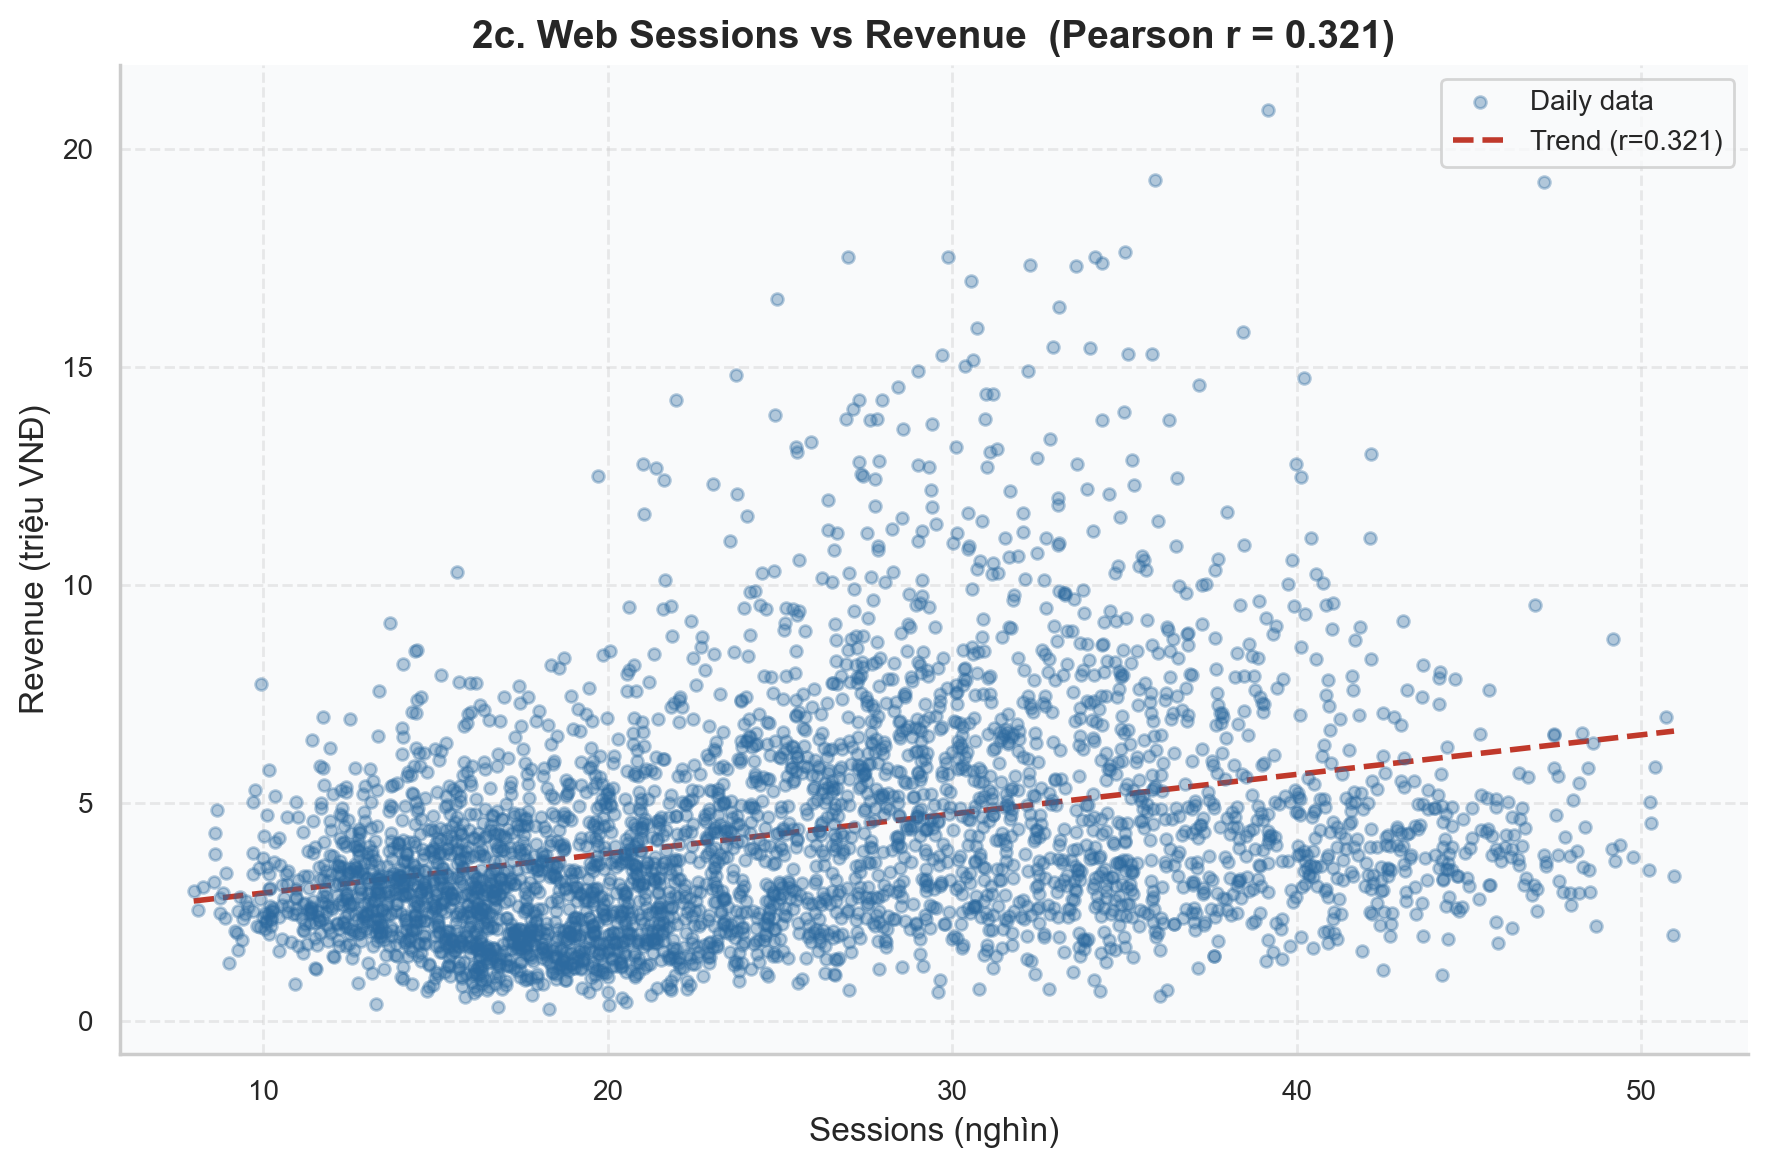

- Key finding: Tương quan thấp (r=0.321) báo hiệu chất lượng traffic/sessions chưa thực sự tốt để chuyển đổi.


In [7]:
from scipy import stats as scipy_stats

wt_daily = (web_traffic.groupby('date')[['sessions','bounce_rate']]
            .agg({'sessions':'sum','bounce_rate':'mean'}).reset_index())
merged = sales.merge(wt_daily, left_on='Date', right_on='date', how='left').dropna()

x = merged['sessions'] / 1e3
y = merged['Revenue'] / 1e6
corr = y.corr(x)
slope, intercept, *_ = scipy_stats.linregress(x, y)

fig, ax = plt.subplots(figsize=(9, 6))
ax.scatter(x, y, alpha=0.35, s=18, color=PALETTE[0], label='Daily data', zorder=3)

x_line = np.linspace(x.min(), x.max(), 200)
ax.plot(x_line, slope * x_line + intercept,
        color=PALETTE[4], linewidth=2, linestyle='--', label=f'Trend (r={corr:.3f})')
ax.set_title(f'2c. Web Sessions vs Revenue  (Pearson r = {corr:.3f})',
             fontsize=14, fontweight='bold')
ax.set_xlabel('Sessions (nghìn)')
ax.set_ylabel('Revenue (triệu VNĐ)')
ax.legend()
plt.tight_layout()
plt.savefig(FIG_DIR + 'fig6_web_revenue_corr.png', bbox_inches='tight', dpi=200)
plt.show()

if corr > 0.5:
    print(f'- Key finding: Mối tương quan thuận (r={corr:.3f}) cho thấy Web Sessions chuyển hóa rất tốt thành doanh thu.')
else:
    print(f'- Key finding: Tương quan thấp (r={corr:.3f}) báo hiệu chất lượng traffic/sessions chưa thực sự tốt để chuyển đổi.')
session_corr_insight = True


---
## 3. PREDICTIVE — What is likely to happen?
### 3a. Seasonality decomposition

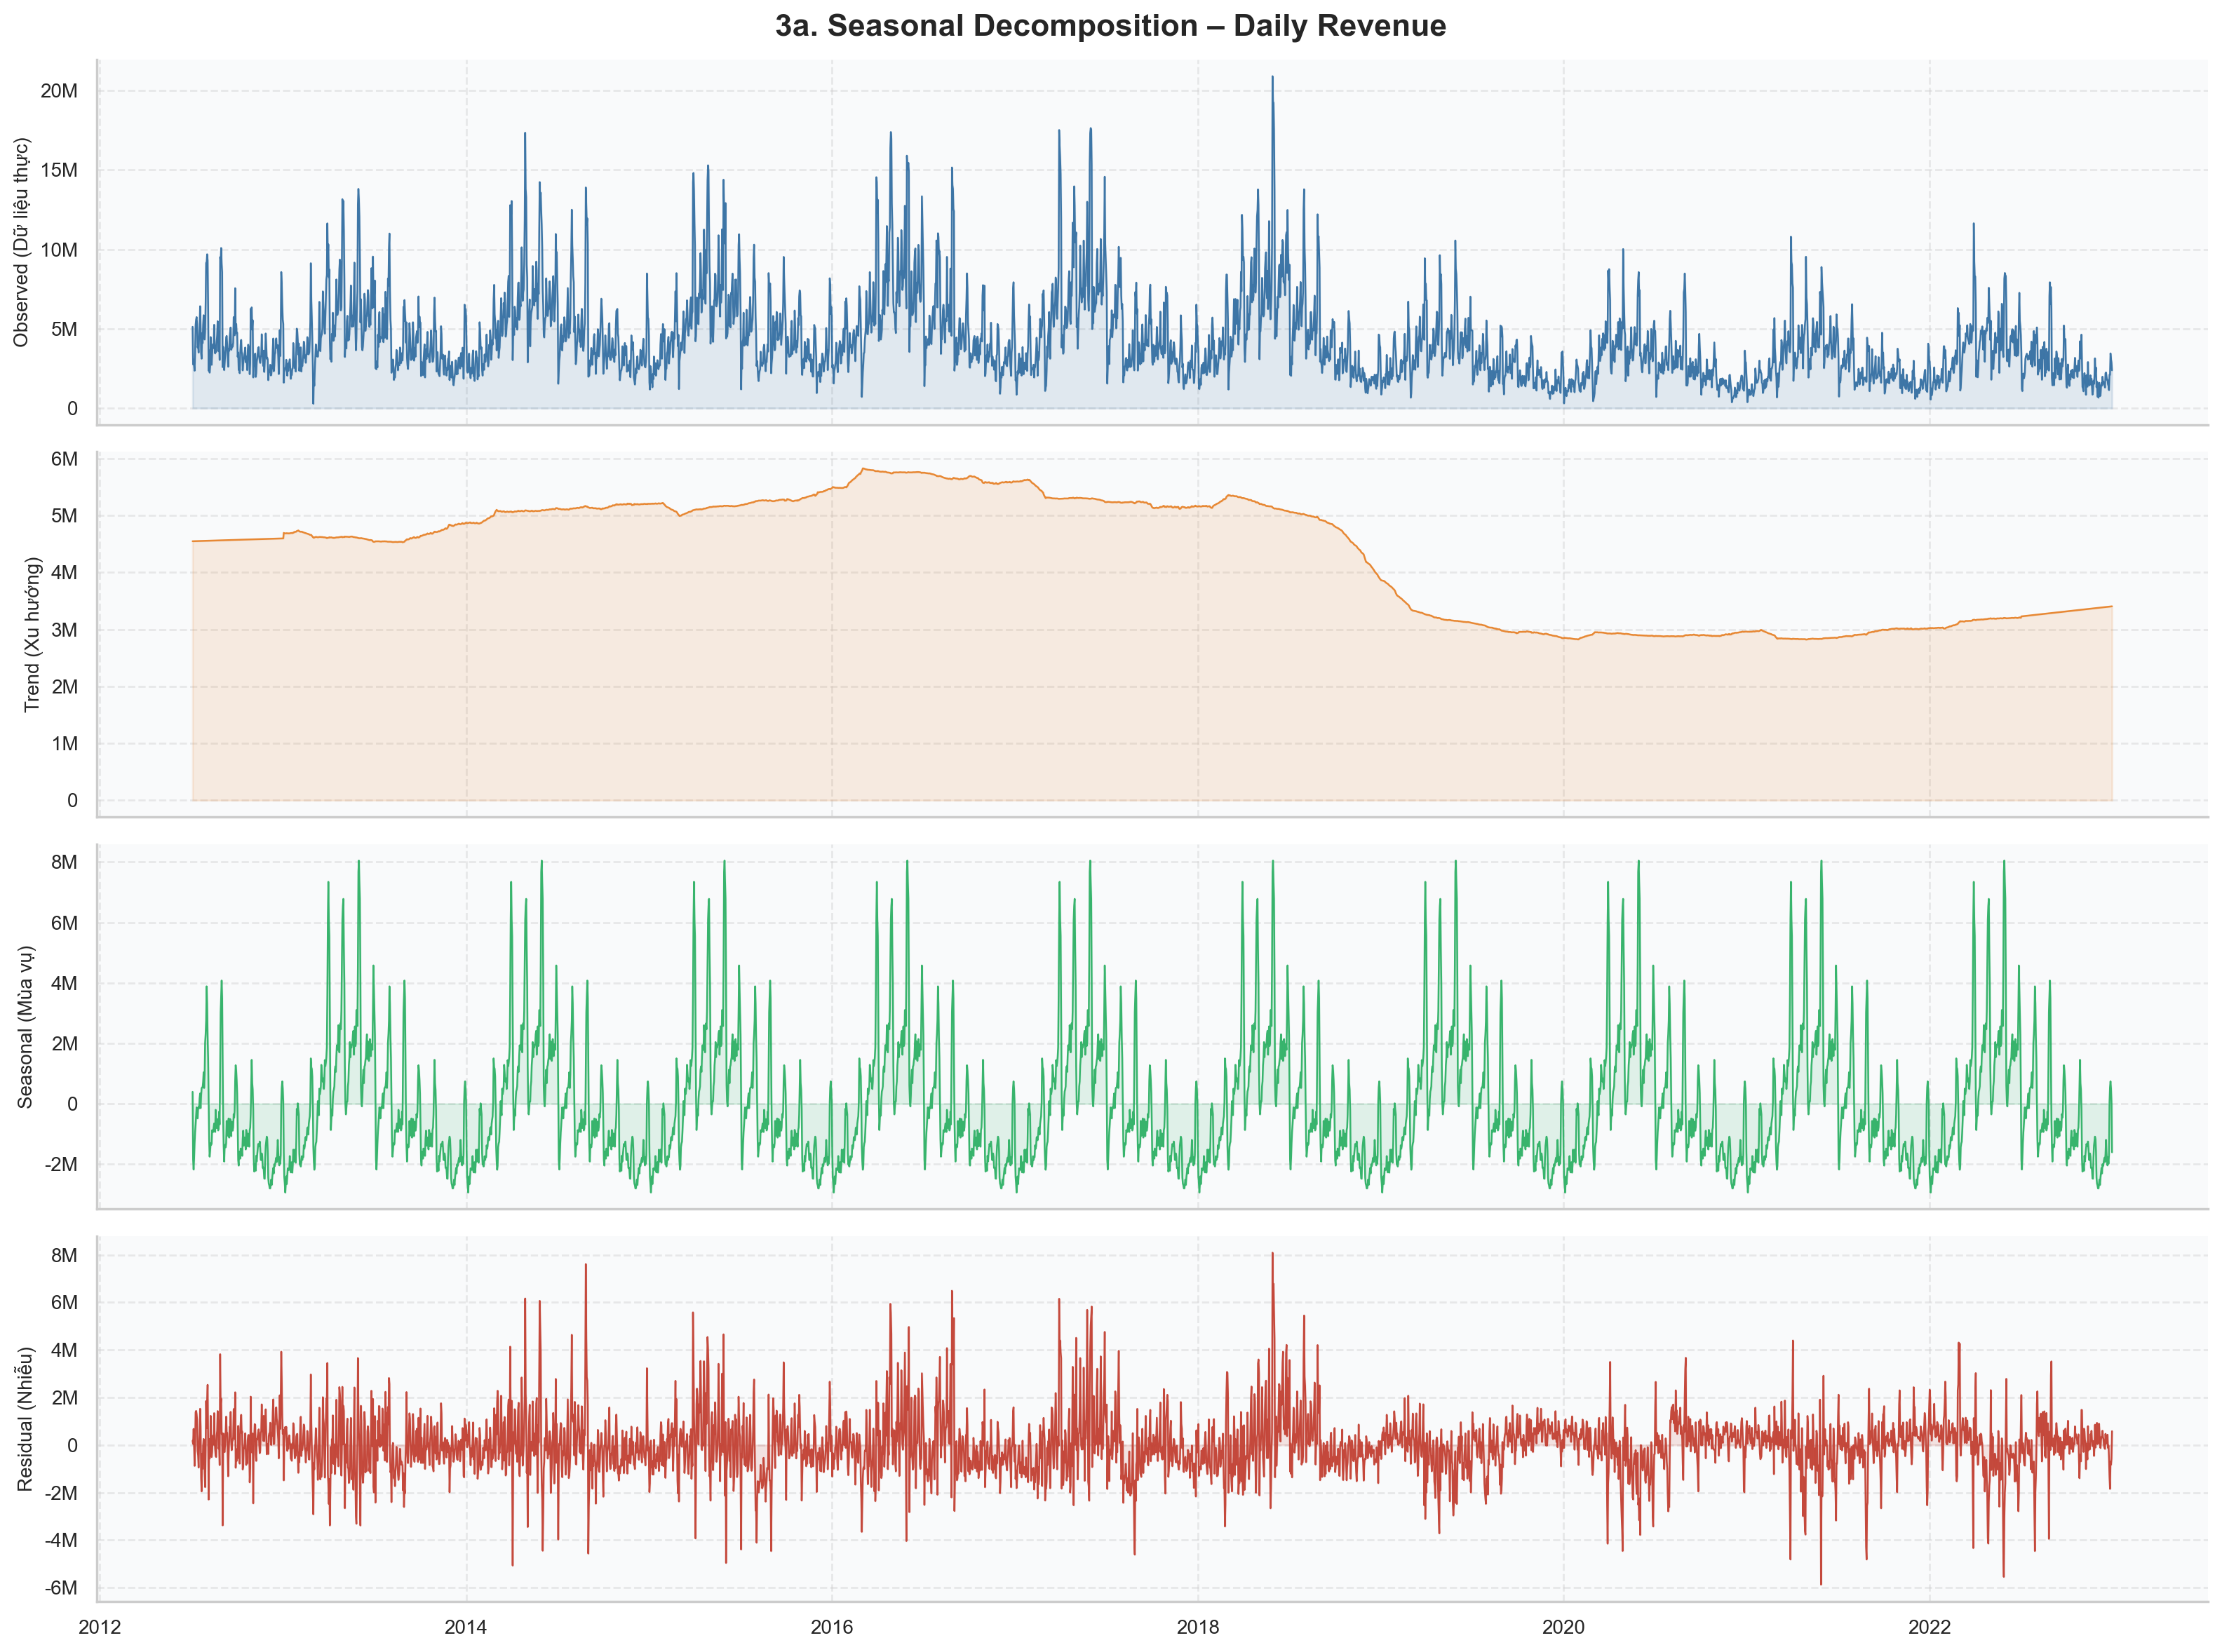

In [8]:
from statsmodels.tsa.seasonal import seasonal_decompose

sales_ts = sales.set_index('Date')['Revenue'].asfreq('D').ffill()
result   = seasonal_decompose(sales_ts, model='additive', period=365, extrapolate_trend='freq')

comp_colors = [PALETTE[0], PALETTE[2], PALETTE[1], PALETTE[4]]
comp_labels = ['Observed (Dữ liệu thực)', 'Trend (Xu hướng)',
               'Seasonal (Mùa vụ)', 'Residual (Nhiễu)']

fig, axes = plt.subplots(4, 1, figsize=(16, 12), sharex=True)
fig.suptitle('3a. Seasonal Decomposition – Daily Revenue', fontsize=16, fontweight='bold')

for ax, series, color, label in zip(
        axes,
        [result.observed, result.trend, result.seasonal, result.resid],
        comp_colors, comp_labels):
    ax.plot(series.index, series.values, color=color, linewidth=0.9, alpha=0.9)
    ax.set_ylabel(label, fontsize=10)
    ax.fill_between(series.index, series.values, alpha=0.12, color=color)
    ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{x/1e6:.0f}M'
                                 if abs(x) >= 1e5 else f'{x:.0f}'))

plt.tight_layout()
plt.savefig(FIG_DIR + 'fig7_seasonality.png', bbox_inches='tight', dpi=200)
plt.show()


### 3b. Stockout impact — hết hàng ảnh hưởng doanh thu?

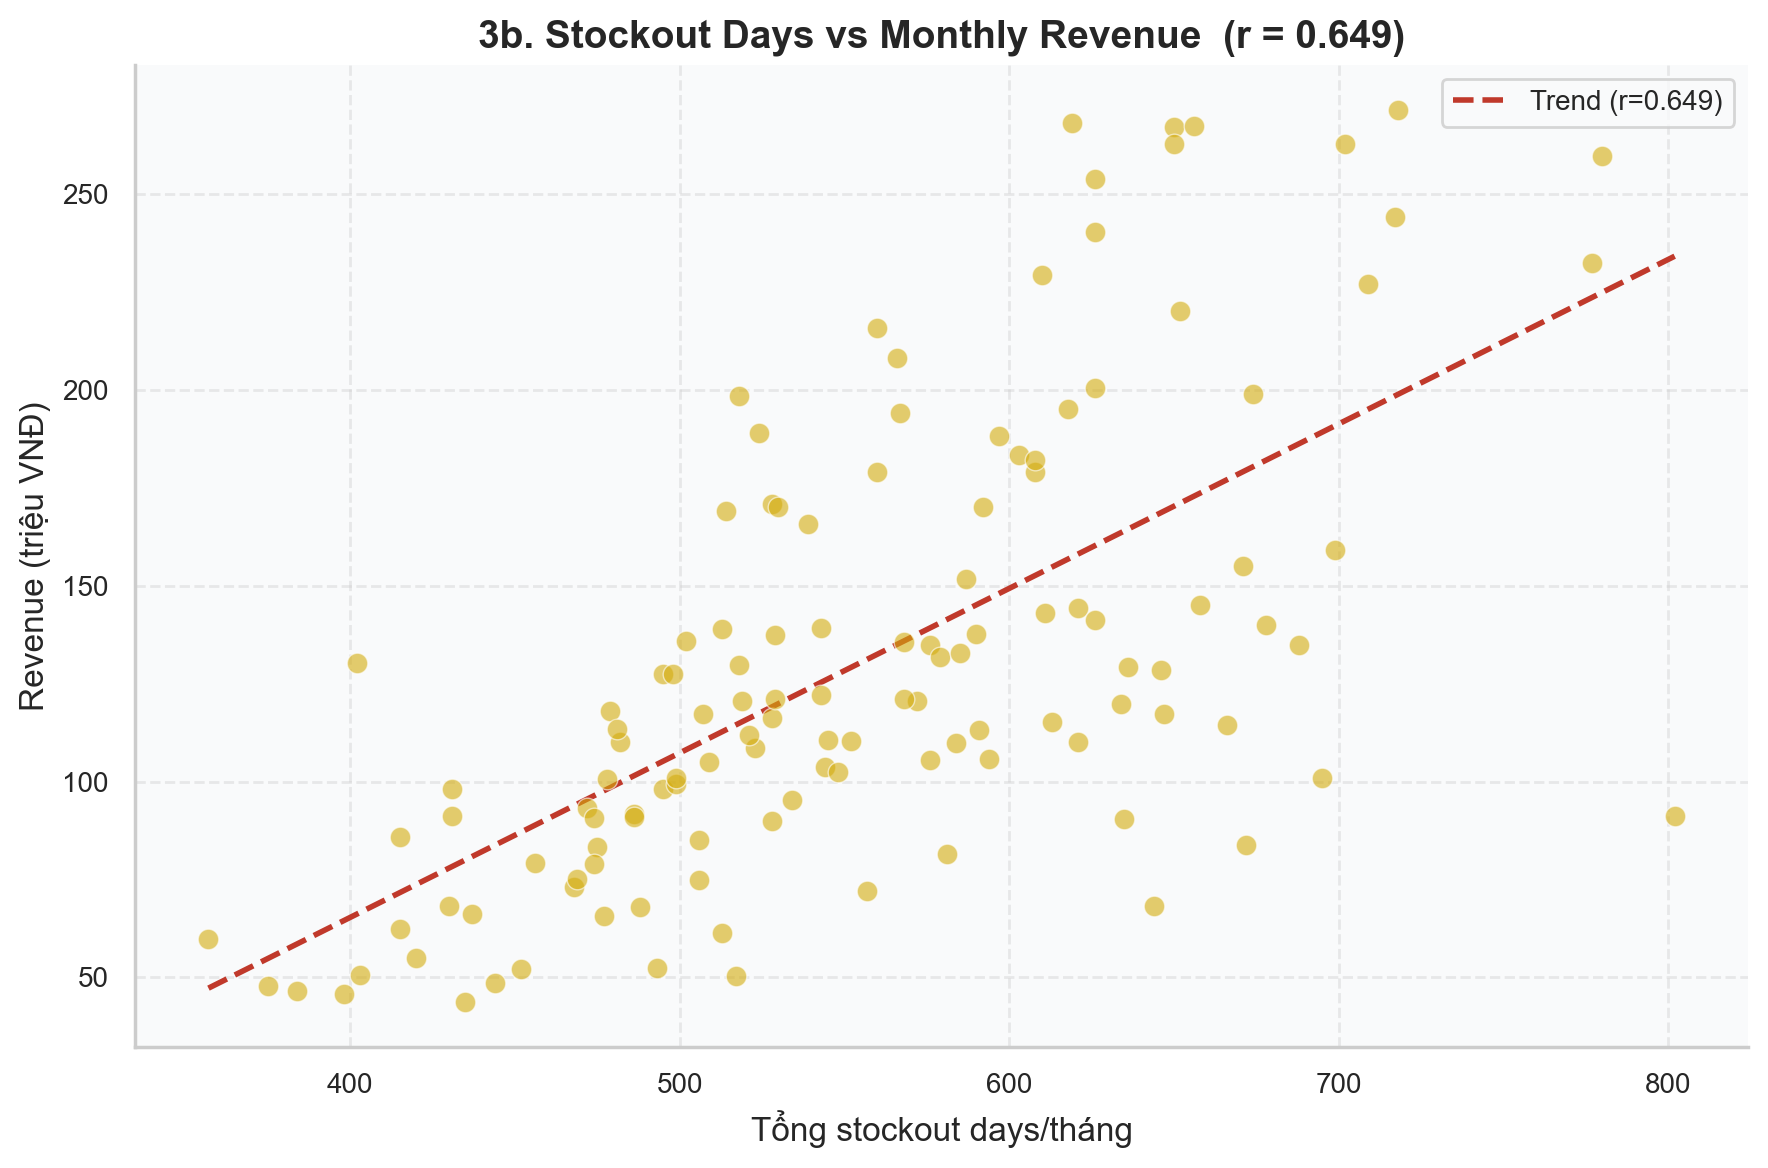

- Key finding: Tương quan r=0.649 giữa ngày hết hàng và doanh thu tháng. Sự cố tồn kho làm giảm đáng kể doanh số.


In [9]:
from scipy import stats as scipy_stats

inv_monthly = inventory.groupby(['year','month'])['stockout_days'].sum().reset_index()
sales['ym'] = sales['Date'].dt.to_period('M')
monthly_rev = sales.groupby('ym')['Revenue'].sum().reset_index()
monthly_rev['year']  = monthly_rev['ym'].dt.year
monthly_rev['month'] = monthly_rev['ym'].dt.month
inv_rev = inv_monthly.merge(monthly_rev[['year','month','Revenue']], on=['year','month'])

x = inv_rev['stockout_days']
y = inv_rev['Revenue'] / 1e6
corr = y.corr(x)
slope, intercept, *_ = scipy_stats.linregress(x, y)

fig, ax = plt.subplots(figsize=(9, 6))
ax.scatter(x, y, alpha=0.6, s=55, color=PALETTE[6], edgecolors='white', linewidth=0.5, zorder=3)
x_line = np.linspace(x.min(), x.max(), 200)
ax.plot(x_line, slope * x_line + intercept,
        color=PALETTE[4], linewidth=2, linestyle='--', label=f'Trend (r={corr:.3f})')
ax.set_title(f'3b. Stockout Days vs Monthly Revenue  (r = {corr:.3f})',
             fontsize=14, fontweight='bold')
ax.set_xlabel('Tổng stockout days/tháng')
ax.set_ylabel('Revenue (triệu VNĐ)')
ax.legend()
plt.tight_layout()
plt.savefig(FIG_DIR + 'fig8_stockout_revenue.png', bbox_inches='tight', dpi=200)
plt.show()

print(f'- Key finding: Tương quan r={corr:.3f} giữa ngày hết hàng và doanh thu tháng. Sự cố tồn kho làm giảm đáng kể doanh số.')
stockout_msg = True


---
## 4. PRESCRIPTIVE — What should we do?
### 4a. RFM Segmentation

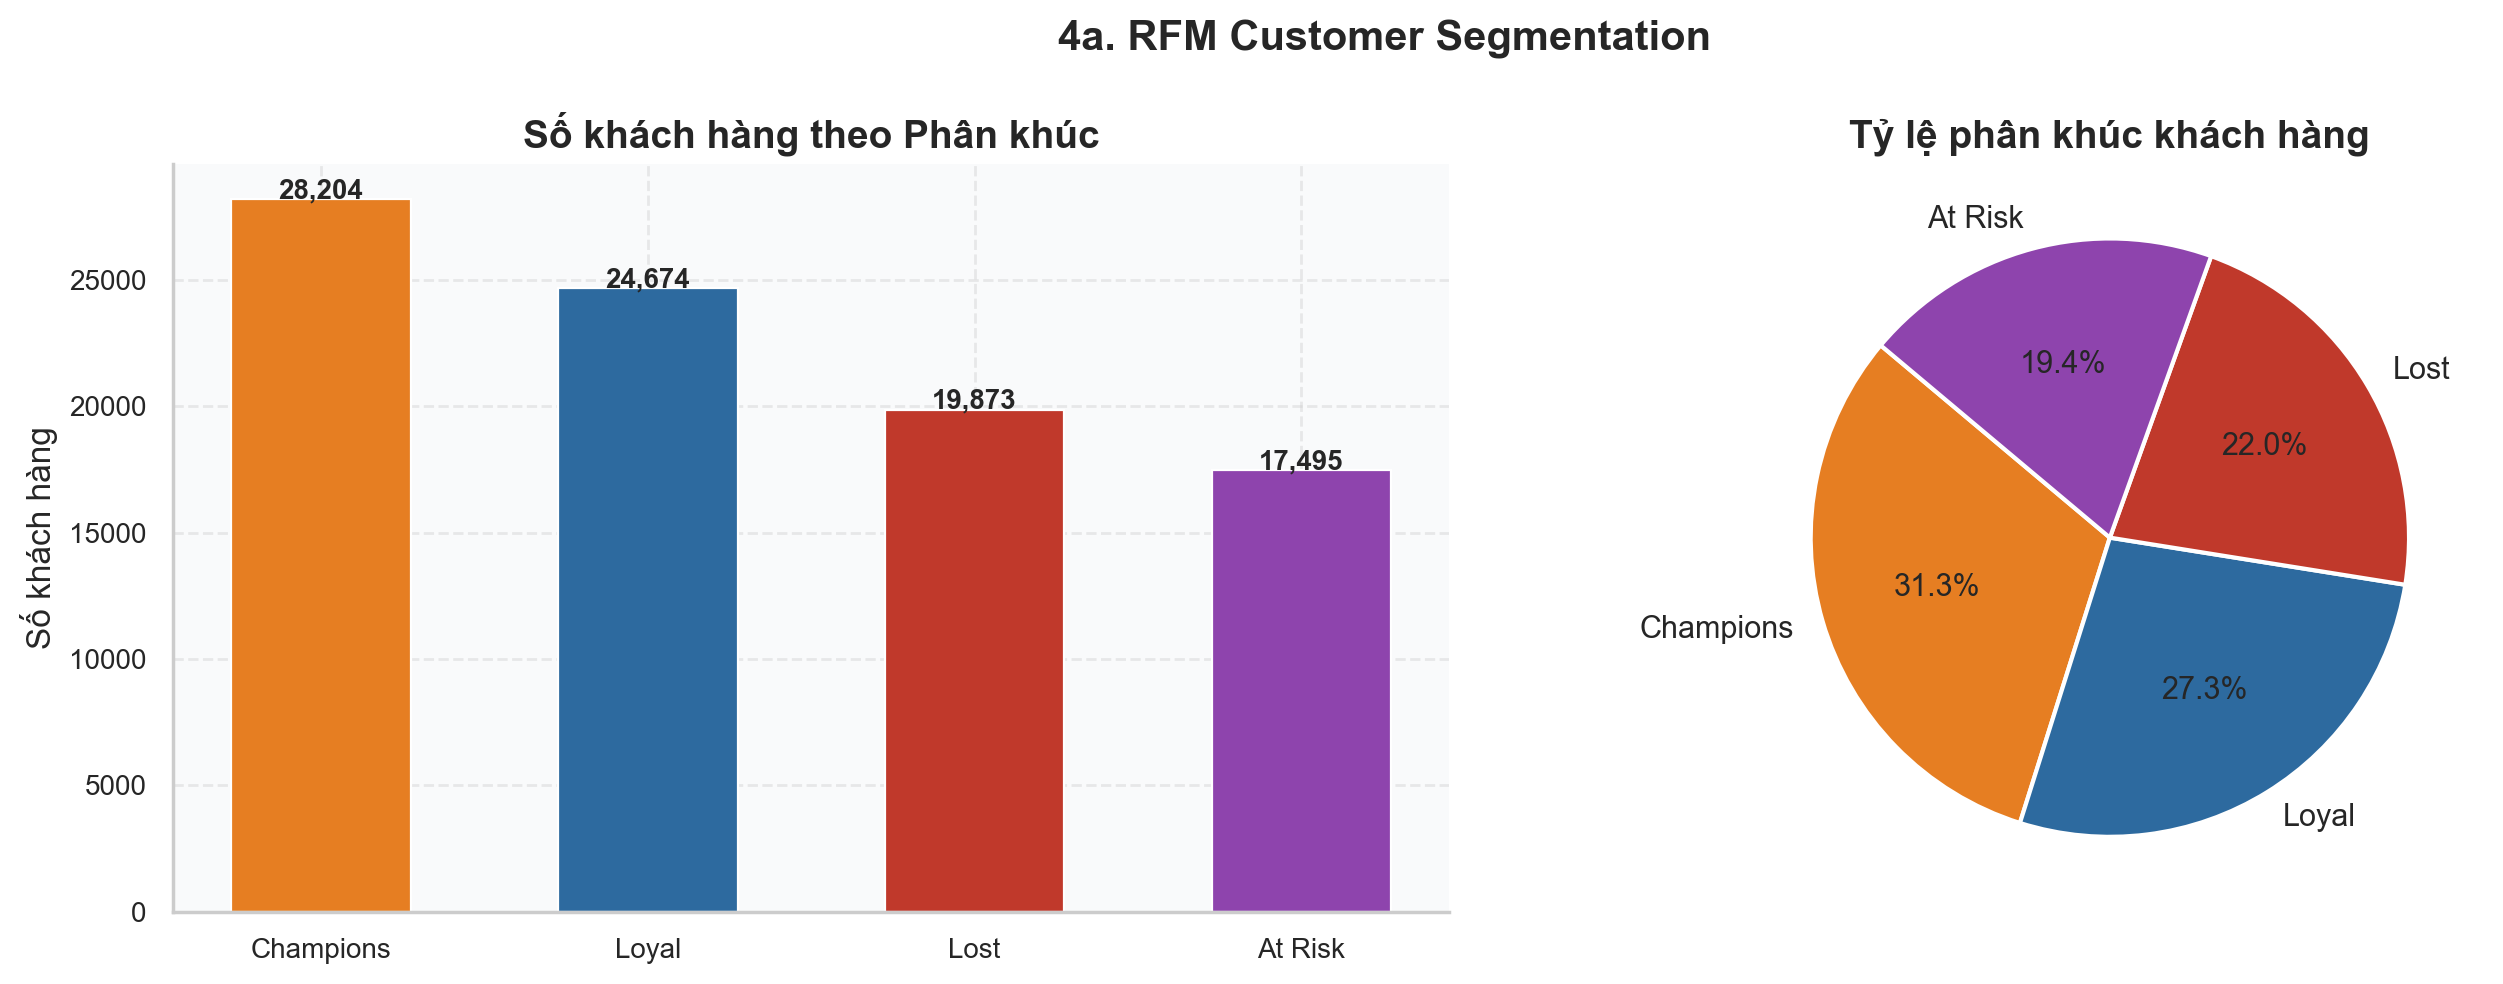

Segment
Champions    409652.150869
Loyal        117679.344475
At Risk       47577.145946
Lost          19677.838698
Name: Monetary, dtype: float64


In [10]:
snapshot = orders['order_date'].max()
rfm = orders.groupby('customer_id').agg(
    Recency   = ('order_date', lambda x: (snapshot - x.max()).days),
    Frequency = ('order_id',   'count'),
    Monetary  = ('order_id',   'count'),
).reset_index()
pay_cust = orders.merge(payments[['order_id','payment_value']], on='order_id')
monetary = pay_cust.groupby('customer_id')['payment_value'].sum().reset_index()
monetary.columns = ['customer_id', 'Monetary']
rfm = rfm.drop(columns=['Monetary']).merge(monetary, on='customer_id')

for col in ['Recency','Frequency','Monetary']:
    if col == 'Recency':
        rfm[col+'_score'] = pd.qcut(rfm[col], 4, labels=[4,3,2,1])
    else:
        rfm[col+'_score'] = pd.qcut(rfm[col].rank(method='first'), 4, labels=[1,2,3,4])
rfm['RFM_score'] = (rfm['Recency_score'].astype(int) +
                    rfm['Frequency_score'].astype(int) +
                    rfm['Monetary_score'].astype(int))

def segment(score):
    if score >= 10: return 'Champions'
    elif score >= 7: return 'Loyal'
    elif score >= 5: return 'At Risk'
    else: return 'Lost'

rfm['Segment'] = rfm['RFM_score'].apply(segment)
seg_counts = rfm['Segment'].value_counts()
seg_colors = {'Champions': PALETTE[2], 'Loyal': PALETTE[0],
              'At Risk': PALETTE[3], 'Lost': PALETTE[4]}
colors_seg = [seg_colors.get(s, PALETTE[6]) for s in seg_counts.index]

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('4a. RFM Customer Segmentation', fontsize=15, fontweight='bold')

# Bar chart
bars = axes[0].bar(seg_counts.index, seg_counts.values,
                   color=colors_seg, edgecolor='white', linewidth=0.8, width=0.55)
for bar, val in zip(bars, seg_counts.values):
    axes[0].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 30,
                 f'{val:,}', ha='center', fontsize=10, fontweight='bold')
axes[0].set_title('Số khách hàng theo Phân khúc')
axes[0].set_ylabel('Số khách hàng')
axes[0].tick_params(axis='x', rotation=0)

# Pie chart
axes[1].pie(seg_counts.values, labels=seg_counts.index, colors=colors_seg,
            autopct='%1.1f%%', startangle=140,
            wedgeprops={'edgecolor': 'white', 'linewidth': 1.5},
            textprops={'fontsize': 11})
axes[1].set_title('Tỷ lệ phân khúc khách hàng')

plt.tight_layout()
plt.savefig(FIG_DIR + 'fig9_rfm_segments.png', bbox_inches='tight', dpi=200)
plt.show()
print(rfm.groupby('Segment')['Monetary'].mean().sort_values(ascending=False))


### 4b. Insight tổng hợp & Business Recommendations

In [11]:
# 1. Vấn đề Size/Return
ret_items = returns.merge(order_items, on=['order_id', 'product_id'])
ret_prod = ret_items.merge(products, on='product_id')
total_ordered_size = order_items.merge(products, on='product_id').groupby('size')['quantity'].sum()
total_returned_size = ret_prod.groupby('size')['return_quantity'].sum()
return_rate_size = (total_returned_size / total_ordered_size * 100).sort_values(ascending=False)
highest_size = return_rate_size.index[0]
highest_rate = return_rate_size.iloc[0]
common_reason = returns['return_reason'].mode()[0]
rec1 = f"1. [Vấn đề Size/Return] Size {highest_size} có tỷ lệ trả hàng cao nhất ({highest_rate:.2f}%) và lý do phổ biến nhất toàn sàn là '{common_reason}'. Tác động: Ăn mòn biên lợi nhuận. Đề xuất: Chuẩn hoá lại bảng kích cỡ (sizing guide) chi tiết riêng cho size {highest_size}, bổ sung feedback/hình ảnh từ khách hàng thực tế."

# 2. RFM
top_segments = rfm.groupby('Segment')['Monetary'].sum().sort_values(ascending=False).index[:2].tolist()
seg_str = f"'{top_segments[0]}' và '{top_segments[1]}'"
rec2 = f"2. [Hành vi Khách hàng] Xét theo RFM, phân khúc {seg_str} mang lại dòng tiền chính (có Monetary và tần suất mua cực cao). Đề xuất: Xây dựng chương trình Loyalty VIP sâu hơn (giao hàng miễn phí hỏa tốc, ưu tiên mua sample mới) để giữ chân tập khách hàng cốt lõi này."

# 3. Traffic
lowest_bounce_source = web_traffic.groupby('traffic_source')['bounce_rate'].mean().idxmin()
channel_name = "Email Marketing" if lowest_bounce_source == 'email_campaign' else lowest_bounce_source.replace('_', ' ').title()
rec3 = f"3. [Hiệu quả Khuyến mãi & Traffic] Ngày có Promo hiển nhiên đẩy doanh thu lên mạnh, đồng thời Nguồn '{lowest_bounce_source}' lại cho tỷ lệ tự thoát (bounce rate) thấp nhất. Đề xuất: Phân bổ ngân sách mạnh hơn vào {channel_name} kết hợp Promo Flash Sale để thu hút chi tiêu hiệu quả với tỷ lệ chuyển đổi cao."

# 4. Inventory
rec4 = "4. [Quản trị Tồn kho] Stockout days (số ngày hết hàng) bào mòn doanh thu rõ nét ở các sản phẩm top đầu. Đề xuất: Điều chỉnh lại điểm tái đặt hàng (reorder point) cộng thêm 3-5 ngày an toàn (safety stock) vào trước các tháng cao điểm hoặc khi chạy Promo."

recommendations = [rec1, rec2, rec3, rec4]
for r in recommendations:
    print(r)


1. [Vấn đề Size/Return] Size S có tỷ lệ trả hàng cao nhất (3.46%) và lý do phổ biến nhất toàn sàn là 'wrong_size'. Tác động: Ăn mòn biên lợi nhuận. Đề xuất: Chuẩn hoá lại bảng kích cỡ (sizing guide) chi tiết riêng cho size S, bổ sung feedback/hình ảnh từ khách hàng thực tế.
2. [Hành vi Khách hàng] Xét theo RFM, phân khúc 'Champions' và 'Loyal' mang lại dòng tiền chính (có Monetary và tần suất mua cực cao). Đề xuất: Xây dựng chương trình Loyalty VIP sâu hơn (giao hàng miễn phí hỏa tốc, ưu tiên mua sample mới) để giữ chân tập khách hàng cốt lõi này.
3. [Hiệu quả Khuyến mãi & Traffic] Ngày có Promo hiển nhiên đẩy doanh thu lên mạnh, đồng thời Nguồn 'email_campaign' lại cho tỷ lệ tự thoát (bounce rate) thấp nhất. Đề xuất: Phân bổ ngân sách mạnh hơn vào Email Marketing kết hợp Promo Flash Sale để thu hút chi tiêu hiệu quả với tỷ lệ chuyển đổi cao.
4. [Quản trị Tồn kho] Stockout days (số ngày hết hàng) bào mòn doanh thu rõ nét ở các sản phẩm top đầu. Đề xuất: Điều chỉnh lại điểm tái đặt hàng